## 1. Load features and inspect per bearing
This cell loads time domain features for the 2nd test dataset.
One row is one measurement in time.
Each table shows the first 5 rows for one bearing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/2nd_test/'
df = extract_features(DATA_DIR)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std,Bearing_1_SpecCentroid,Bearing_1_HighFreqRatio,Bearing_1_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.074179,0.628763,6.120331,0.454,0.083993,0.073475,0.295670,0.148204,0.159585
2004-02-12 10:42:39,0.075382,0.648291,5.147086,0.388,0.052142,0.075338,0.315869,0.162889,0.110516
2004-02-12 10:52:39,0.076230,0.513475,6.598472,0.503,0.032808,0.076189,0.309372,0.149281,0.098084
2004-02-12 11:02:39,0.078724,1.157953,7.723217,0.608,0.041486,0.078691,0.310441,0.137911,0.098578
2004-02-12 11:12:39,0.078474,0.603177,4.982524,0.391,0.028224,0.078437,0.311464,0.140996,0.082495


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std,Bearing_2_SpecCentroid,Bearing_2_HighFreqRatio,Bearing_2_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.090944,0.506801,5.640841,0.513,0.126915,0.090053,0.328990,0.255914,0.179857
2004-02-12 10:42:39,0.093419,0.253014,5.148852,0.481,0.070088,0.093384,0.344429,0.274719,0.134815
2004-02-12 10:52:39,0.093718,0.310789,5.367171,0.503,0.096583,0.093703,0.336007,0.260072,0.130946
2004-02-12 11:02:39,0.092947,0.235341,6.121762,0.569,0.105834,0.092916,0.334987,0.256468,0.123872
2004-02-12 11:12:39,0.095348,0.226309,5.097120,0.486,0.097966,0.095335,0.337662,0.261617,0.105419


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std,Bearing_3_SpecCentroid,Bearing_3_HighFreqRatio,Bearing_3_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.109404,3.213075,9.350652,1.023,0.204840,0.108434,0.425442,0.437827,0.034714
2004-02-12 10:42:39,0.109817,1.395250,6.847735,0.752,-0.023854,0.109790,0.415886,0.393227,0.022684
2004-02-12 10:52:39,0.109861,2.639948,8.492546,0.933,0.056561,0.109849,0.430768,0.433500,0.022270
2004-02-12 11:02:39,0.110667,2.682779,9.180734,1.016,0.033550,0.110622,0.429751,0.425092,0.020520
2004-02-12 11:12:39,0.107506,1.578395,7.171719,0.771,-0.002892,0.107499,0.423784,0.404496,0.020388


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std,Bearing_4_SpecCentroid,Bearing_4_HighFreqRatio,Bearing_4_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.054103,0.065959,4.879539,0.264,-0.022080,0.053166,0.266642,0.101812,0.069763
2004-02-12 10:42:39,0.056101,0.107539,4.438435,0.249,0.001582,0.055973,0.298804,0.113079,0.058900
2004-02-12 10:52:39,0.056145,0.257236,6.305078,0.354,0.070449,0.056037,0.291042,0.103658,0.054569
2004-02-12 11:02:39,0.056807,0.806190,9.241749,0.525,-0.036327,0.056684,0.290772,0.104387,0.052089
2004-02-12 11:12:39,0.056841,0.138954,4.292680,0.244,0.019008,0.056777,0.292692,0.106843,0.046722


## 2. All features over the full timeline

One subplot per feature, all 4 bearings in each.
Flat and low means healthy. A sharp rise means the fault starts.

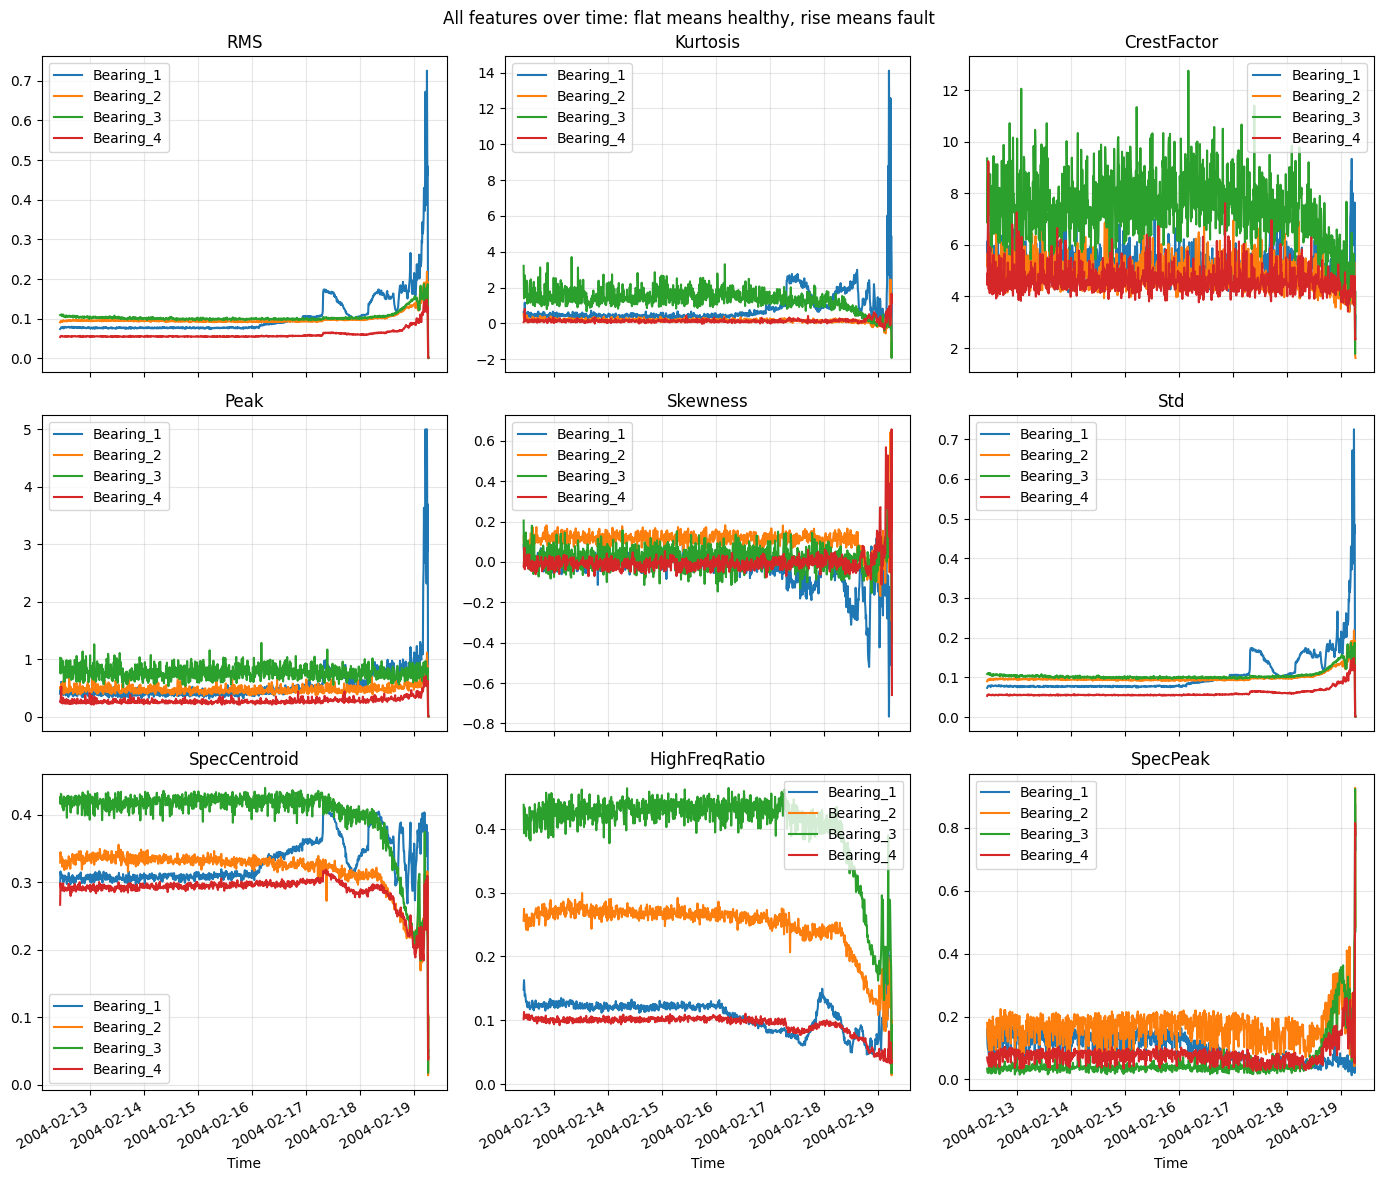

In [2]:
features = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
            'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True)
for ax, feat in zip(axes.flat, features):
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    renamed = {c: c.replace('_' + feat, '') for c in cols}
    df[cols].rename(columns=renamed).plot(ax=ax)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
plt.suptitle('All features over time: flat means healthy, rise means fault')
plt.tight_layout()
plt.show()

## 3. Fault localization: which bearing fails

Compare late against early values per bearing and per feature, no boundary needed.
A healthy channel stays near growth 1. The failed bearing grows on several
independent features at once. Skewness is left out, its healthy baseline sits
near zero so ratios explode.

### How the verdict is computed

1. Take the first 100 rows as the early reference and the last 100 rows as
   the late state.
2. For each bearing and each of RMS, Kurtosis, Peak and Std, divide late
   mean by early mean. That is the growth ratio.
3. Average the four growth ratios per bearing (CrestFactor and Skewness are
   excluded - see note below).
4. The bearing with the highest average growth ratio is printed as faulty.
   Full code lives in `identify_faulty_bearing` in `src/evaluation.py`.

In [3]:
from src.evaluation import identify_faulty_bearing

result = identify_faulty_bearing(df)
display(result['summary'])
print(f"Faulty bearing: {result['faulty_bearing']}")

,rms_growth,kurtosis_growth,crest_factor_growth,peak_growth,std_growth
bearing,,,,,
Bearing_1,2.79,3.64,0.96,2.86,2.79
Bearing_2,1.38,0.06,0.83,1.16,1.38
Bearing_3,1.29,0.10,0.74,0.94,1.29
Bearing_4,1.56,1.51,0.91,1.42,1.56


Faulty bearing: Bearing_1


### Reading the table above

Row by row: RMS and Std almost tripled on Bearing 1 only.
Peak nearly tripled on Bearing 1 only.
Kurtosis more than tripled on Bearing 1 only, the strongest single witness,
which fits an impulsive fault.
CrestFactor sinks below 1 on all bearings, the known late fault signature
where RMS has caught up with Peak.

**Why Skewness is excluded:** its healthy baseline sits near zero (for example
0.03), so late divided by early explodes into numbers like -14 that mean nothing.
It stays in the section 4 plots where its late swinging is visible directly.
For a ratio table it would only add noise, so the table keeps the five features
where division is meaningful.

How to read the values: every number is a quotient, late mean divided by early mean.
Near 1 means late looks like early, no change. Far from 1 means change.
Rows do not share one reading direction, each row has its own logic, so what
counts as bad differs per feature, as explained row by row below.
RMS and Std near 1.3 to 1.6 is normal drift, 2.79 means vibration energy
almost tripled. Peak near 1 means impacts unchanged, 2.86 means impacts
nearly tripled. Kurtosis near 0.1 to 1.5 is calm, 3.64 means heavy spiking
from impacts, the strongest single witness of an impulsive fault.
CrestFactor below 1 on all bearings is the late fault signature,
RMS has caught up with Peak everywhere.
The code prints the bearing with the highest average across the four growing
features, Bearing_1 at 3.02 against 1.51 for the runner up. No extra metric
is invented, the table holds only the five growth features and the winner
is read straight from them.
Documentation agrees (outer race), as confirmation only.

## 4. Faulty bearing in detail

The previous section identified Bearing 1.
Each feature has its own plot because features use different scales.
Look at which feature reacts first when the fault starts.

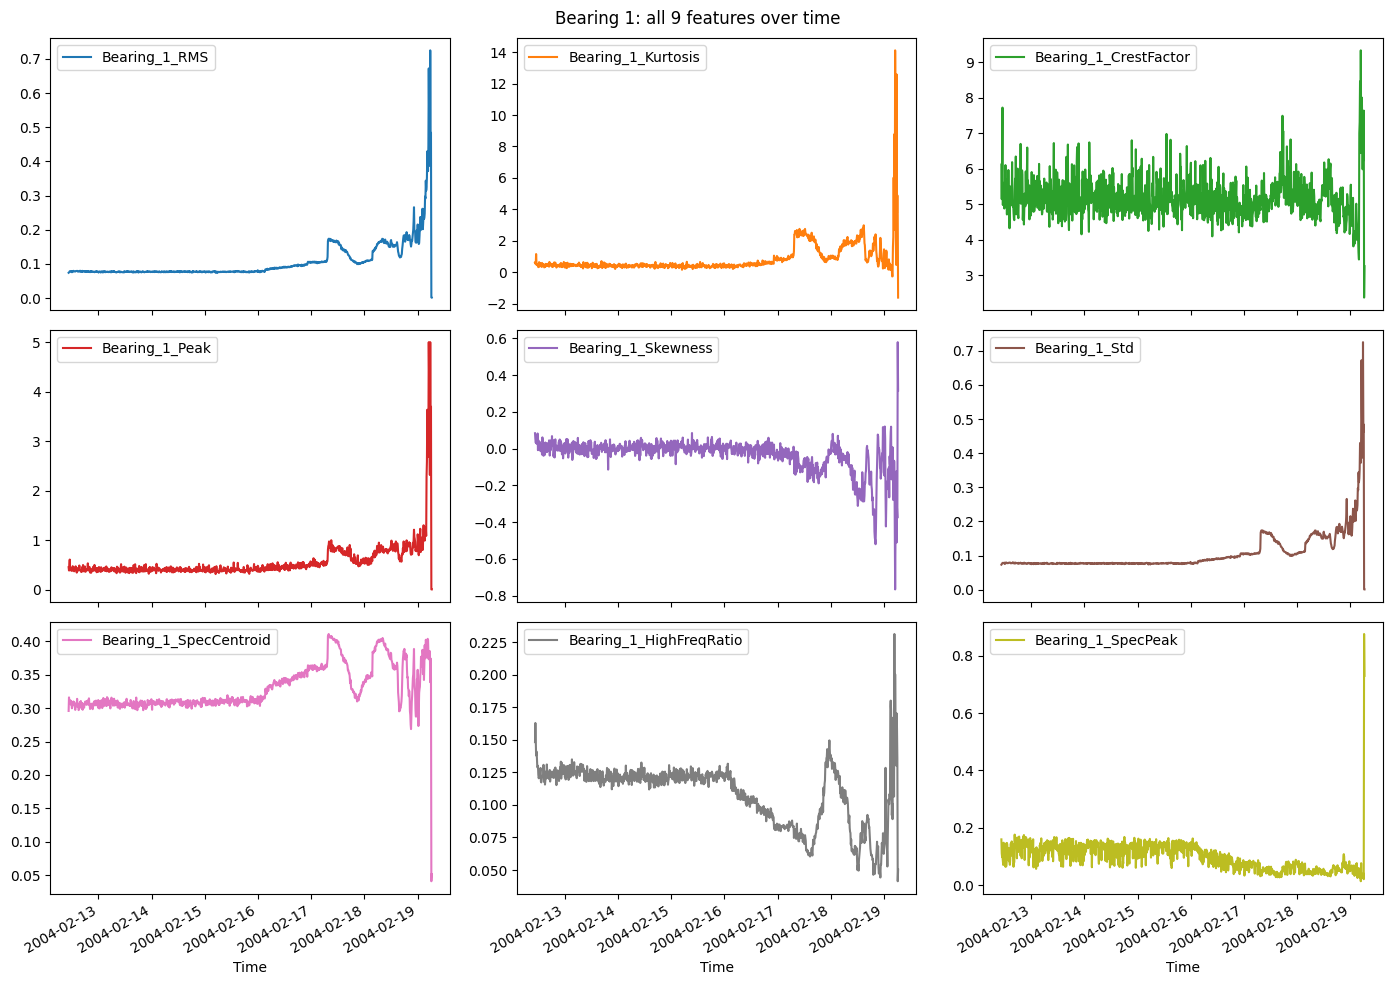

In [4]:
bearing1_cols = [c for c in df.columns if 'Bearing_1_' in c]
df[bearing1_cols].plot(figsize=(14, 10), subplots=True, layout=(3, 3))
plt.suptitle('Bearing 1: all 9 features over time')
plt.tight_layout()
plt.show()

## 5. Compare healthy boundary candidates
Try several boundary dates on Bearing_1_RMS and compare them side by side.
A good boundary keeps FPR low while giving enough healthy samples for training.
If the first alarm moves later when the boundary moves later, the boundary
has swallowed the start of the fault and is too late.

In [5]:
from src.evaluation import compare_boundaries

scores = df['Bearing_1_RMS']
candidates = [
    pd.Timestamp('2004-02-14 12:00:00'),
    pd.Timestamp('2004-02-14 18:00:00'),
    pd.Timestamp('2004-02-15 00:00:00'),
    pd.Timestamp('2004-02-15 06:00:00'),
    pd.Timestamp('2004-02-15 12:00:00'),
    pd.Timestamp('2004-02-16 00:00:00'),
    pd.Timestamp('2004-02-16 06:00:00'),
    pd.Timestamp('2004-02-16 12:00:00'),
    pd.Timestamp('2004-02-16 18:00:00'),
    pd.Timestamp('2004-02-17 00:00:00'),
]
compare_boundaries(scores, candidates)

,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-02-14 12:00:00,297,0.080486,2004-02-16 06:22:39,0.000000
1,2004-02-14 18:00:00,333,0.080461,2004-02-16 06:22:39,0.000000
2,2004-02-15 00:00:00,369,0.080421,2004-02-16 06:22:39,0.000000
3,2004-02-15 06:00:00,405,0.080460,2004-02-16 06:22:39,0.000000
4,2004-02-15 12:00:00,441,0.080361,2004-02-16 06:22:39,0.000000
5,2004-02-16 00:00:00,513,0.080459,2004-02-16 06:22:39,0.001949
6,2004-02-16 06:00:00,549,0.082455,2004-02-16 06:32:39,0.029144
7,2004-02-16 12:00:00,585,0.087362,2004-02-16 12:32:39,0.044444
8,2004-02-16 18:00:00,621,0.092661,2004-02-16 18:32:39,0.027375
9,2004-02-17 00:00:00,657,0.099424,2004-02-17 01:32:39,0.015221


### Reading the table above

- **Rows for 2004-02-14 12:00 through 2004-02-16 00:00** (6 candidates):
  threshold stays flat (~0.0804), first_alarm is identical every time
  (2004-02-16 06:22:39), FPR stays near zero. This means the fault has NOT
  started yet in this range - safe to use as "healthy" training data.
- **Rows from 2004-02-16 06:00 onward**: threshold keeps rising
  (0.082 -> 0.099), and first_alarm keeps shifting later (06:32 -> 12:32 ->
  18:32 -> next day 01:32). This is the signature of contamination: the
  fault has already begun, so including this period as "healthy" trains the
  model to treat early fault symptoms as normal, delaying detection.
- **Conclusion**: the widest safe boundary is 2004-02-16 00:00:00 - the last
  candidate before results start changing.

## 6. Decision: chosen healthy boundary

We choose 2004-02-16 00:00:00 (513 healthy samples) - the widest boundary
that still gives stable results, per the interpretation above.

In [6]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-02-16')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-02-16 00:00:00


## 7. Split into healthy / full dataset

Using the boundary chosen above. We further split the healthy period into
a training part (fits the model/scaler) and a validation part (sets the
threshold). This avoids computing the threshold on the same data the model
was fit on, which would bias it optimistically - per advisor feedback.

In [7]:
from src.preprocessing import split_healthy, scale_features, split_train_val

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
df_healthy_train, df_healthy_val = split_train_val(df_healthy, val_fraction=0.2)

print(f"Healthy total: {len(df_healthy)}")
print(f"Healthy train: {len(df_healthy_train)} ({df_healthy_train.index[0]} to {df_healthy_train.index[-1]})")
print(f"Healthy val:   {len(df_healthy_val)} ({df_healthy_val.index[0]} to {df_healthy_val.index[-1]})")

X_healthy_train, X_all, scaler = scale_features(df_healthy_train, df)
X_healthy_val = scaler.transform(df_healthy_val)
input_dim = X_healthy_train.shape[1]
n_spectral = len([c for c in df.columns if 'Spec' in c or 'High' in c])
print(f"Feature dimension: {input_dim} ({input_dim - n_spectral} time + {n_spectral} spectral)")

Healthy total: 513
Healthy train: 411 (2004-02-12 10:32:39 to 2004-02-15 06:52:39)
Healthy val:   102 (2004-02-15 07:02:39 to 2004-02-15 23:52:39)
Feature dimension: 36 (24 time + 12 spectral)


## 8. Classical models

Fit each detector on the TRAINING part of the healthy data only, then
compute its threshold from the held-out VALIDATION part (not seen during
fitting). Score the full timeline and compare first alarm and FPR.
Models train on all features together, time and spectral.

In [8]:
from src.classical_models import (
    fit_isolation_forest, score_isolation_forest,
    fit_one_class_svm, score_one_class_svm,
    fit_lof, score_lof,
    fit_pca, score_pca,
)
from src.evaluation import compute_threshold, first_confirmed_alarm, false_positive_rate
import numpy as np

def evaluate(name, full_scores, val_scores, index):
    val_mean = float(np.mean(val_scores))
    val_std = float(np.std(val_scores))
    print(f"{name}: val_scores mean={val_mean:.5f}  std={val_std:.5f}")

    scores_series = pd.Series(full_scores, index=index)
    threshold = compute_threshold(val_scores, method="mean_std", n_std=3.0)
    print(f"{name}: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")

    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[index <= train_end].mean())
    fpr_val = float(is_anomaly[(index > train_end) & (index <= val_end)].mean())
    print(f"{name}: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
    print()
    return {"scores": scores_series, "val_mean": val_mean, "val_std": val_std,
            "threshold": float(threshold), "alarm": alarm,
            "fpr_train": fpr_train, "fpr_val": fpr_val}
classical = [
    ('IsolationForest', fit_isolation_forest, score_isolation_forest),
    ('OneClassSVM', fit_one_class_svm, score_one_class_svm),
    ('LOF', fit_lof, score_lof),
    ('PCA', fit_pca, score_pca),
]

classical_results = {}
for name, fit_fn, score_fn in classical:
    model = fit_fn(X_healthy_train)
    full_scores = score_fn(model, X_all)
    val_scores = score_fn(model, X_healthy_val)
    classical_results[name] = evaluate(name, full_scores, val_scores, df.index)
OLD6 = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']
old_cols = [c for c in df.columns if any(c.endswith('_' + f) for f in OLD6)]
Xtr_old, Xa_old, sc_old = scale_features(df_healthy_train[old_cols], df[old_cols])
Xva_old = sc_old.transform(df_healthy_val[old_cols])
old_results = {}
for name, fit_fn, score_fn in classical:
    model = fit_fn(Xtr_old)
    full_scores = score_fn(model, Xa_old)
    val_scores = score_fn(model, Xva_old)
    old_results[name] = evaluate(name, full_scores, val_scores, df.index)

def _astr(a):
    return a.strftime('%Y-%m-%d %H:%M:%S') if a is not None else None
side_rows = []
for name, _, _ in classical:
    r36, r24 = classical_results[name], old_results[name]
    side_rows.append({'model': name, 'alarm_24': _astr(r24['alarm']), 'alarm_36': _astr(r36['alarm']),
                       'fpr_24': round(r24['fpr_val'], 4), 'fpr_36': round(r36['fpr_val'], 4)})
print("Joint results: old 24 time features vs all 36 with spectral:")
display(pd.DataFrame(side_rows))

IsolationForest: val_scores mean=0.43538  std=0.02556
IsolationForest: threshold = 0.43538 + 3*0.02556 = 0.51205
IsolationForest: first_alarm=2004-02-17 01:32:39  fpr_train=0.0341  fpr_val=0.0000 (primary)

OneClassSVM: val_scores mean=-0.11931  std=0.09439
OneClassSVM: threshold = -0.11931 + 3*0.09439 = 0.16387
OneClassSVM: first_alarm=2004-02-16 06:22:39  fpr_train=0.0000  fpr_val=0.0000 (primary)



LOF: val_scores mean=1.05879  std=0.06687
LOF: threshold = 1.05879 + 3*0.06687 = 1.25941
LOF: first_alarm=2004-02-16 06:22:39  fpr_train=0.0219  fpr_val=0.0196 (primary)

PCA: val_scores mean=0.04055  std=0.02699
PCA: threshold = 0.04055 + 3*0.02699 = 0.12152
PCA: first_alarm=2004-02-16 16:42:39  fpr_train=0.0122  fpr_val=0.0098 (primary)

IsolationForest: val_scores mean=0.43148  std=0.02951
IsolationForest: threshold = 0.43148 + 3*0.02951 = 0.51999
IsolationForest: first_alarm=2004-02-17 10:22:39  fpr_train=0.0316  fpr_val=0.0000 (primary)

OneClassSVM: val_scores mean=-0.11021  std=0.08738
OneClassSVM: threshold = -0.11021 + 3*0.08738 = 0.15192
OneClassSVM: first_alarm=2004-02-16 06:22:39  fpr_train=0.0000  fpr_val=0.0196 (primary)



LOF: val_scores mean=1.07513  std=0.08476
LOF: threshold = 1.07513 + 3*0.08476 = 1.32941
LOF: first_alarm=2004-02-16 06:22:39  fpr_train=0.0292  fpr_val=0.0098 (primary)

PCA: val_scores mean=0.02465  std=0.01916
PCA: threshold = 0.02465 + 3*0.01916 = 0.08212
PCA: first_alarm=2004-02-17 02:52:39  fpr_train=0.0292  fpr_val=0.0196 (primary)

Joint results: old 24 time features vs all 36 with spectral:


,model,alarm_24,alarm_36,fpr_24,fpr_36
0,IsolationForest,2004-02-17 10:22:39,2004-02-17 01:32:39,0.0000,0.0000
1,OneClassSVM,2004-02-16 06:22:39,2004-02-16 06:22:39,0.0196,0.0000
2,LOF,2004-02-16 06:22:39,2004-02-16 06:22:39,0.0098,0.0196
3,PCA,2004-02-17 02:52:39,2004-02-16 16:42:39,0.0196,0.0098


In [9]:
classical_summary_df = pd.DataFrame([{
    'model': name,
    'val_mean': r['val_mean'],
    'val_std': r['val_std'],
    'threshold': r['threshold'],
    'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
    'fpr_train': r['fpr_train'],
    'fpr_val': r['fpr_val'],
} for name, r in classical_results.items()]).sort_values('model').reset_index(drop=True)
display(classical_summary_df.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
    'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.43538,0.02556,0.51205,2004-02-17 01:32:39,0.0341,0.0000
1,LOF,1.05879,0.06687,1.25941,2004-02-16 06:22:39,0.0219,0.0196
2,OneClassSVM,-0.11931,0.09439,0.16387,2004-02-16 06:22:39,0.0000,0.0000
3,PCA,0.04055,0.02699,0.12152,2004-02-16 16:42:39,0.0122,0.0098


Why two FPR numbers: FPR on the train part alone overestimates quality,
it measures how well the model recognizes data it already saw during fitting
rather than how well it generalizes. fpr_val is the reported metric.

## 9. Joint vs separate training

Same four models on three kinds of input. all_24 is the original joint setup:
24 time features together, kept as the reference from before spectral features
existed. all_36 is the current joint setup: all 24 plus 12 spectral features
together. The rest are single feature types across all 4 bearings. Both joint
rows reuse the section 8 results, nothing is retrained for them. Shows whether
the combination beats any single feature on its own.

In [10]:
def alarm_and_fpr(scores_series, threshold):
    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[scores_series.index <= train_end].mean())
    fpr_val = float(is_anomaly[(scores_series.index > train_end) & (scores_series.index <= val_end)].mean())
    alarm_str = alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None
    return alarm_str, round(fpr_train, 4), round(fpr_val, 4)

comparison = []
for name, _, _ in classical:
    r = old_results[name]
    comparison.append({'setup': 'all_24', 'model': name,
                       'alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': round(r['fpr_train'], 4), 'fpr_val': round(r['fpr_val'], 4)})
for name, _, _ in classical:
    r = classical_results[name]
    alarm, fpr_train, fpr_val = alarm_and_fpr(r['scores'], r['threshold'])
    comparison.append({'setup': 'all_36', 'model': name, 'alarm': alarm,
                       'fpr_train': fpr_train, 'fpr_val': fpr_val})

feature_types = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
                   'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
for feat in feature_types:
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    Xtr_f, Xa_f, sc_f = scale_features(df_healthy_train[cols], df[cols])
    Xva_f = sc_f.transform(df_healthy_val[cols])
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr_f)
        full_scores = score_fn(model, Xa_f)
        val_scores = score_fn(model, Xva_f)
        threshold = compute_threshold(val_scores, method="mean_std", n_std=3.0)
        alarm, fpr_train, fpr_val = alarm_and_fpr(pd.Series(full_scores, index=df.index), threshold)
        comparison.append({'setup': feat, 'model': name, 'alarm': alarm,
                           'fpr_train': fpr_train, 'fpr_val': fpr_val})

order = ['all_24', 'all_36'] + feature_types
comp_df = pd.DataFrame(comparison)
comp_df['setup'] = pd.Categorical(comp_df['setup'], categories=order, ordered=True)
comp_df = comp_df.sort_values(['setup', 'model']).reset_index(drop=True)
print("First confirmed alarm per setup and model (None = the model never alarmed):")
display(comp_df.pivot_table(index='setup', columns='model', values='alarm', aggfunc='first', observed=True))
print("False positive rate on VALIDATION per setup and model (primary, unseen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))
print("False positive rate on TRAIN per setup and model (sanity check, seen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_train', aggfunc='first', observed=True).style.format('{:.4f}'))

First confirmed alarm per setup and model (None = the model never alarmed):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 02:52:39
all_36,2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 16:42:39
RMS,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:52:39
Kurtosis,2004-02-17 09:42:39,2004-02-17 05:52:39,2004-02-17 01:32:39,2004-02-17 10:22:39
CrestFactor,NaN,2004-02-19 05:52:39,NaN,NaN
Peak,2004-02-17 10:42:39,2004-02-17 10:12:39,2004-02-17 10:12:39,2004-02-18 09:42:39
Skewness,2004-02-18 20:02:39,2004-02-17 20:42:39,2004-02-18 12:32:39,NaN
Std,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:02:39
SpecCentroid,2004-02-18 00:42:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:12:39


False positive rate on VALIDATION per setup and model (primary, unseen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0000,0.0098,0.0196,0.0196
all_36,0.0000,0.0196,0.0000,0.0098
RMS,0.0000,0.0098,0.0098,0.0196
Kurtosis,0.0000,0.0196,0.0098,0.0294
CrestFactor,0.0000,0.0196,0.0196,0.0294
Peak,0.0000,0.0196,0.0098,0.0294
Skewness,0.0196,0.0294,0.0196,0.0098
Std,0.0000,0.0098,0.0098,0.0000
SpecCentroid,0.0000,0.0098,0.0098,0.0294


False positive rate on TRAIN per setup and model (sanity check, seen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0316,0.0292,0.0000,0.0292
all_36,0.0341,0.0219,0.0000,0.0122
RMS,0.0097,0.0170,0.0000,0.0073
Kurtosis,0.0341,0.0292,0.0000,0.0316
CrestFactor,0.0170,0.0268,0.0000,0.0243
Peak,0.0170,0.0316,0.0000,0.0268
Skewness,0.0146,0.0243,0.0000,0.0219
Std,0.0097,0.0195,0.0000,0.0438
SpecCentroid,0.0097,0.0049,0.0000,0.0365


### Reading the comparison above

No setup wins everywhere, the table must be read per model. SVM and LOF alarm
on 16.02 at 06:22 with all 36 features, and RMS, Std and SpecCentroid alone
match them to the minute, which confirms those three carry the fault signal
on their own.

Kurtosis alone alarms later than the joint setup on every model: about 23 hours
later for LOF, 19 for SVM, 8 for IsolationForest and 18 for PCA. Peak and
Skewness are consistently a day or more late in most cases.
CrestFactor alone mostly never alarms - three of four models return no
confirmed alarm at all, and the one exception (LOF, firing on 19.02) comes at
the very end of the recorded test.

With spectral features the IsolationForest story flipped: the joint setup at
01:32 now beats every single feature, best single RMS and Std at 05:52.
The combination is now strictly earlier here, not just more robust.

PCA behaves differently from the other three models when restricted to a
single feature type: with only 4 input columns, `n_components=0.95` keeps all 4
components, so nothing is compressed, validation reconstruction error collapses
close to zero and the resulting threshold becomes extremely tight. This makes the
per-feature PCA alarms harder to trust as a measure of feature quality
specifically - the model is reacting to a near-zero threshold rather than to
a clearly learned "normal" pattern. The joint 36-feature PCA result does not
have this problem, since 18 of 36 components are kept, and its
alarm (16.02 16:42) is the one PCA number used with confidence in this
comparison.

The FPR table tells a different story than the alarm table, and only the
validation column counts: fpr_val uses data the model never saw, fpr_train
is a sanity check. On fpr_val, IsolationForest is cleanest at 0.0000 in 8 of 11
setups. OneClassSVM sits at 0.0000 to 0.0196, yet it alarms earliest at 16.02
06:22 wherever the signal allows. The verdict splits: IsolationForest cries wolf
the least, OneClassSVM balances early alarms with low false rates, making it the
strongest single candidate if only one classical model had to be chosen.

The joint 36-feature setup is now the earliest choice for IsolationForest (01:32
against 05:52 best single) and tied for LOF and SVM (06:22). Only for PCA do
singles alarm earlier (RMS 07:52, Std 07:02 against joint 16:42), but per-feature
PCA thresholds are degenerate and machine dependent, so that comparison carries
no weight. Had someone tracked only CrestFactor or Skewness upfront, the fault
would be missed entirely or caught days late. The combination needs no lucky
pick, and now it also leads on speed wherever the numbers can be trusted. Among
the four algorithms, OneClassSVM offers the best combination of a low false
positive rate and a competitive alarm time, making it the strongest single
candidate for this dataset if only one classical model had to be chosen.

## 10. One bearing at a time

Train every classical model on a single bearing's 9 features.
Shows which bearing drives detection, a model based confirmation
of the section 3 localization. Deep models are skipped here,
4 bearings times 9 trainings each would be too expensive.

In [11]:
bearings = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

bearing_rows = []
for b in bearings:
    cols = [c for c in df.columns if c.startswith(b + '_')]
    Xtr_b, Xa_b, sc_b = scale_features(df_healthy_train[cols], df[cols])
    Xva_b = sc_b.transform(df_healthy_val[cols])
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr_b)
        full = pd.Series(score_fn(model, Xa_b), index=df.index)
        val = score_fn(model, Xva_b)
        threshold = compute_threshold(val, method="mean_std", n_std=3.0)
        is_an = full > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        train_end = df_healthy_train.index[-1]
        val_end = df_healthy.index[-1]
        fpr_train = float(is_an[(full.index <= train_end)].mean())
        fpr_val = float(is_an[(full.index > train_end) & (full.index <= val_end)].mean())
        bearing_rows.append({'bearing': b, 'model': name,
                             'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                             'fpr_train': round(fpr_train, 4), 'fpr_val': round(fpr_val, 4)})

bear_df = pd.DataFrame(bearing_rows)
print("First confirmed alarm per bearing and model (None = the model never alarmed):")
display(bear_df.pivot_table(index='bearing', columns='model', values='alarm', aggfunc='first', observed=True))
print("False positive rate on VALIDATION per bearing and model (primary, unseen data):")
display(bear_df.pivot_table(index='bearing', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))

First confirmed alarm per bearing and model (None = the model never alarmed):


model,IsolationForest,LOF,OneClassSVM,PCA
bearing,,,,
Bearing_1,2004-02-16 08:02:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 05:22:39
Bearing_2,2004-02-17 17:02:39,2004-02-17 22:32:39,2004-02-17 22:22:39,2004-02-18 14:42:39
Bearing_3,2004-02-18 14:02:39,2004-02-18 12:22:39,2004-02-18 11:42:39,2004-02-19 05:32:39
Bearing_4,2004-02-17 10:22:39,2004-02-17 02:52:39,2004-02-17 10:12:39,2004-02-18 17:22:39


False positive rate on VALIDATION per bearing and model (primary, unseen data):


model,IsolationForest,LOF,OneClassSVM,PCA
bearing,,,,
Bearing_1,0.0196,0.0196,0.0098,0.0294
Bearing_2,0.0000,0.0000,0.0000,0.0392
Bearing_3,0.0098,0.0196,0.0098,0.0098
Bearing_4,0.0098,0.0196,0.0000,0.0294


## 11. Visual check: model score vs. threshold over time

Plotting the model's actual anomaly score (not raw RMS) against its
threshold, to visually confirm where the alarm fires relative to the
overall shape of the signal.

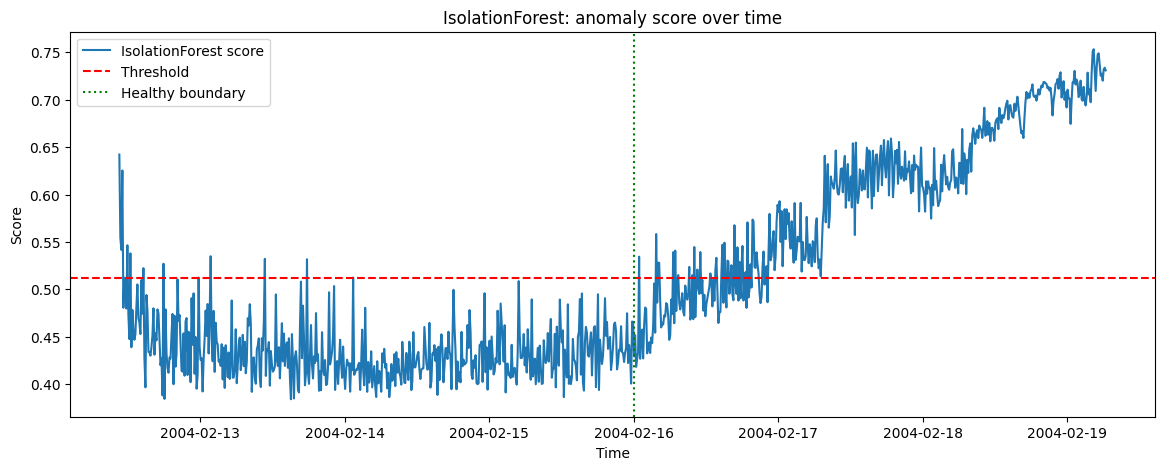

In [12]:
import matplotlib.pyplot as plt

name_to_check = "IsolationForest"
res_to_plot = classical_results[name_to_check]
scores_series, threshold = res_to_plot['scores'], res_to_plot['threshold']

plt.figure(figsize=(14, 5))
plt.plot(scores_series.index, scores_series.values, label=f"{name_to_check} score")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.axvline(HEALTHY_BOUNDARY, color="green", linestyle=":", label="Healthy boundary")
plt.legend()
plt.title(f"{name_to_check}: anomaly score over time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.show()

## 12. Boundary sensitivity check

Same procedure as sections 7 and 8, repeated for boundaries shifted around
the chosen HEALTHY_BOUNDARY. The chosen boundary stays official, this only
checks how sensitive first_alarm and FPR are to that decision.

First confirmed alarm per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
-12h,2004-02-17 02:02:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 13:12:39
-6h,2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 16:42:39
chosen (0h),2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 16:42:39
+6h,2004-02-17 10:22:39,2004-02-16 09:42:39,NaN,2004-02-16 21:02:39
+12h,2004-02-17 10:32:39,2004-02-17 00:12:39,NaN,2004-02-17 10:22:39


Validation FPR per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
-12h,0.0000,0.0114,0.0000,0.0227
-6h,0.0000,0.0211,0.0000,0.0105
chosen (0h),0.0000,0.0196,0.0000,0.0098
+6h,0.0000,0.0183,0.0000,0.0183
+12h,0.0000,0.0000,0.0000,0.0085


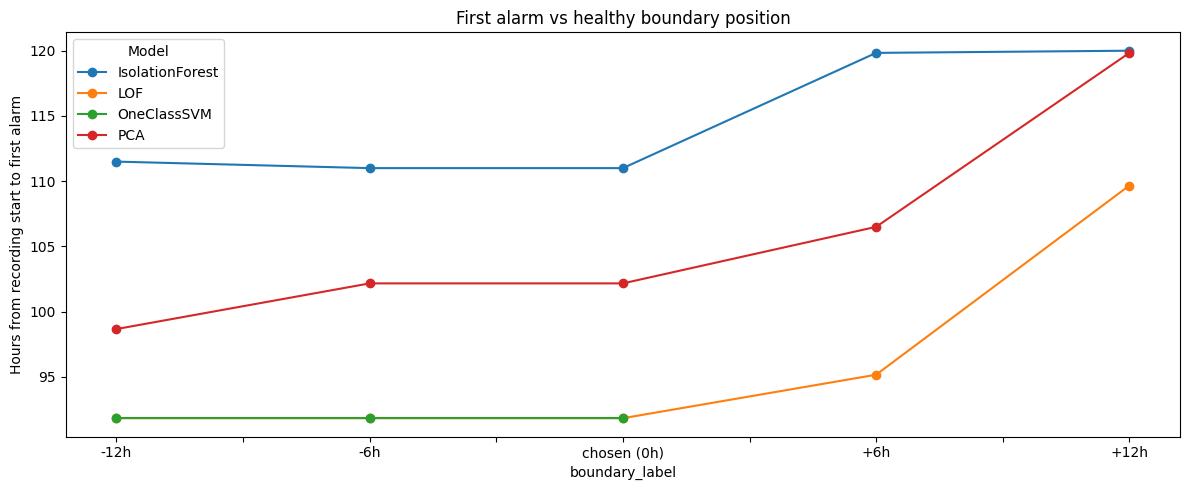

In [13]:
boundary_candidates = {
    '-12h': HEALTHY_BOUNDARY - pd.Timedelta(hours=12),
    '-6h': HEALTHY_BOUNDARY - pd.Timedelta(hours=6),
    'chosen (0h)': HEALTHY_BOUNDARY,
    '+6h': HEALTHY_BOUNDARY + pd.Timedelta(hours=6),
    '+12h': HEALTHY_BOUNDARY + pd.Timedelta(hours=12),
}

sens_rows = []
for label, b in boundary_candidates.items():
    df_h = split_healthy(df, b)
    df_tr, df_va = split_train_val(df_h, val_fraction=0.2)
    Xtr, Xa_, sc_ = scale_features(df_tr, df)
    Xva_ = sc_.transform(df_va)
    train_end, val_end = df_tr.index[-1], df_h.index[-1]
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr)
        full = pd.Series(score_fn(model, Xa_), index=df.index)
        val = score_fn(model, Xva_)
        threshold = compute_threshold(val, method="mean_std", n_std=3.0)
        is_an = full > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        fpr_v = float(is_an[(full.index > train_end) & (full.index <= val_end)].mean())
        sens_rows.append({'boundary_label': label, 'model': name,
                         'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                         'fpr': round(fpr_v, 4)})

order12 = ['-12h', '-6h', 'chosen (0h)', '+6h', '+12h']
sens_df = pd.DataFrame(sens_rows)
sens_df['boundary_label'] = pd.Categorical(sens_df['boundary_label'], categories=order12, ordered=True)
sens_df = sens_df.sort_values(['boundary_label', 'model']).reset_index(drop=True)
print("First confirmed alarm per boundary and model:")
display(sens_df.pivot_table(index='boundary_label', columns='model', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per boundary and model:")
display(sens_df.pivot_table(index='boundary_label', columns='model', values='fpr', aggfunc='first', observed=True).style.format('{:.4f}'))
plot_sens = sens_df.copy()
plot_sens['alarm_h'] = (pd.to_datetime(plot_sens['alarm']) - df.index[0]).dt.total_seconds() / 3600
plot_sens.pivot_table(index='boundary_label', columns='model', values='alarm_h', observed=True).plot(kind='line', marker='o', figsize=(12, 5))
plt.ylabel('Hours from recording start to first alarm')
plt.title('First alarm vs healthy boundary position')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Reading the sensitivity check

Each model reacts very differently to the same 6-24 hour shift in the
healthy/full boundary - this matters more than which model "wins" on the
chosen boundary alone.

- **IsolationForest**: nearly identical on the early side (-12h within 30 minutes
  of chosen) and breaks at +6h, jumping about 9 hours later and holding there
  at +12h. Note the FPR actually drops to 0.0000 at +12h - this looks like an
  improvement but is not: the threshold has been pushed so high (by training
  on data that already contains early fault symptoms) that almost nothing
  crosses it anymore, healthy or not. A falling FPR paired with a much later
  alarm is a red flag, not good news.
- **LOF**: degrades gradually - exact alarm through 0h, then slips by about
  3.5 hours at +6h and 17 hours at +12h. No sudden break, just a smooth
  delay. This is the "softest" failure mode of the four.

- **OneClassSVM**: the most fragile by far. It matches the other models
  exactly on the early side (-12h to 0h), but at +6h and +12h it stops
  alarming entirely (first_alarm = NaN) - including through the catastrophic
  end-of-life spike visible in section 2's plot. This is not a delay, it is
  a silent, complete failure: once early fault symptoms are folded into
  "healthy" training data, the learned boundary widens so much that even
  the worst-case failure no longer looks anomalous. A 6-hour boundary error
  is enough to make this specific model produce zero alarms for the rest
  of the dataset.

- **PCA**: drifts across about 21 hours with no sharp break and no missed alarms,
  the widest span of the four, but still gradual.
Validation FPR stays low everywhere (0.0000-0.0227) regardless of boundary,
which is precisely why FPR alone cannot be used to judge these models here -
a model can have a great FPR while having silently stopped detecting
anything (see OneClassSVM above). First-alarm timing and whether an alarm
fires at all are the metrics that actually reveal fragility.

**Conclusion**: this check does not prove 2004-02-16 is the objectively
correct boundary (there is no independent ground truth for the exact fault
onset), but it shows the chosen boundary sits in a mostly stable region: exact on
the early side for IF, LOF and SVM, drifting for PCA. It also surfaces a finding independent
of boundary choice: OneClassSVM is far less robust than the other three
detectors to this specific methodological decision, which is itself worth
reporting as a comparison dimension - not just detection speed, but
robustness to how the healthy period is defined.

## 13. Scaler robustness check

Same joint setup under three scalers. Alarms stand still except PCA shifting
about 2 hours earlier with Standard and Robust, with slightly cleaner FPRs
and never worse anywhere. Recorded here so the scaler choice is documented;
the pipeline itself still runs on MinMaxScaler until a switch is decided.

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

scaler_rows = []
for sname, Scaler in [('MinMax', MinMaxScaler), ('Standard', StandardScaler), ('Robust', RobustScaler)]:
    sc_c = Scaler()
    Xtr_c = sc_c.fit_transform(df_healthy_train)
    Xa_c = sc_c.transform(df)
    Xva_c = sc_c.transform(df_healthy_val)
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr_c)
        full = pd.Series(score_fn(model, Xa_c), index=df.index)
        val = score_fn(model, Xva_c)
        threshold = compute_threshold(val, method="mean_std", n_std=3.0)
        is_an = full > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        train_end = df_healthy_train.index[-1]
        val_end = df_healthy.index[-1]
        fpr_v = float(is_an[(full.index > train_end) & (full.index <= val_end)].mean())
        scaler_rows.append({'scaler': sname, 'model': name,
                           'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                           'fpr': round(fpr_v, 4)})

order_sc = ['MinMax', 'Standard', 'Robust']
scal_df = pd.DataFrame(scaler_rows)
scal_df['scaler'] = pd.Categorical(scal_df['scaler'], categories=order_sc, ordered=True)
scal_df = scal_df.sort_values(['model', 'scaler']).reset_index(drop=True)
print("First confirmed alarm per scaler and model:")
display(scal_df.pivot_table(index='model', columns='scaler', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per scaler and model:")
display(scal_df.pivot_table(index='model', columns='scaler', values='fpr', aggfunc='first', observed=True).style.format('{:.4f}'))

First confirmed alarm per scaler and model:


scaler,MinMax,Standard,Robust
model,,,
IsolationForest,2004-02-17 01:32:39,2004-02-17 01:32:39,2004-02-17 01:32:39
LOF,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
OneClassSVM,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
PCA,2004-02-16 16:42:39,2004-02-16 22:42:39,2004-02-17 00:12:39


Validation FPR per scaler and model:


scaler,MinMax,Standard,Robust
model,,,
IsolationForest,0.0000,0.0000,0.0000
LOF,0.0196,0.0098,0.0196
OneClassSVM,0.0000,0.0000,0.0000
PCA,0.0098,0.0294,0.0196


## 14. Deep models

Same procedure as classical: train on the healthy train part only, threshold on
validation errors, alarm and FPR on the full timeline. Three dense architectures
(3 runs each) plus one LSTM autoencoder on windowed data.

In [15]:
from src.deep_models import (
    build_autoencoder, build_lstm_autoencoder, make_windows,
    run_multiple, reconstruction_error, reconstruction_error_lstm,
)

deep_results = {}
architectures = {
    'AE_1layer': [8],
    'AE_2layer': [12, 6],
    'AE_3layer': [16, 8, 4],
}
for name, hidden_layers in architectures.items():
    build_fn = lambda hl=hidden_layers: build_autoencoder(input_dim, hl)
    mean_full, _ = run_multiple(build_fn, X_healthy_train, X_all,
                                error_fn=reconstruction_error,
                                n_runs=3, epochs=50, batch_size=32)
    mean_val, _ = run_multiple(build_fn, X_healthy_train, X_healthy_val,
                               error_fn=reconstruction_error,
                               n_runs=3, epochs=50, batch_size=32)
    val_mean = float(np.mean(mean_val))
    val_std = float(np.std(mean_val))
    print(f"{name}: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
    scores_series = pd.Series(mean_full, index=df.index)
    threshold = compute_threshold(mean_val, method="mean_std", n_std=3.0)
    print(f"{name}: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[df.index <= train_end].mean())
    fpr_val = float(is_anomaly[(df.index > train_end) & (df.index <= val_end)].mean())
    print(f"{name}: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
    print()
    deep_results[name] = {"scores": scores_series, "val_mean": val_mean, "val_std": val_std,
                          "threshold": float(threshold),
                          "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

WINDOW_SIZE = 10
X_healthy_windows = make_windows(X_healthy_train, WINDOW_SIZE)
X_all_windows = make_windows(X_all, WINDOW_SIZE)
X_val_windows = make_windows(X_healthy_val, WINDOW_SIZE)
lstm_index = df.index[WINDOW_SIZE - 1:]
build_lstm_fn = lambda: build_lstm_autoencoder(WINDOW_SIZE, input_dim, encoding_dim=8)
lstm_full, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_all_windows,
                            error_fn=reconstruction_error_lstm,
                            n_runs=1, epochs=50, batch_size=32)
lstm_val, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_val_windows,
                           error_fn=reconstruction_error_lstm,
                           n_runs=1, epochs=50, batch_size=32)
val_mean = float(np.mean(lstm_val))
val_std = float(np.std(lstm_val))
print(f"LSTM_AE: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
lstm_series = pd.Series(lstm_full, index=lstm_index)
threshold = compute_threshold(lstm_val, method="mean_std", n_std=3.0)
print(f"LSTM_AE: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = lstm_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=20)
lstm_mask = lstm_index <= val_end
lstm_train_end = df_healthy_train.index[-1]
fpr_train = float(is_anomaly[(lstm_index <= lstm_train_end)].mean())
fpr_val = float(is_anomaly[(lstm_index > lstm_train_end) & lstm_mask].mean())
print(f"LSTM_AE: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
deep_results['LSTM_AE'] = {"scores": lstm_series, "val_mean": val_mean, "val_std": val_std,
                           "threshold": float(threshold),
                           "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

AE_1layer: val_errors mean=0.02427  std=0.00845
AE_1layer: threshold = 0.02427 + 3*0.00845 = 0.04961
AE_1layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0292  fpr_val=0.0098 (primary)



AE_2layer: val_errors mean=0.02025  std=0.00726
AE_2layer: threshold = 0.02025 + 3*0.00726 = 0.04203
AE_2layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0170  fpr_val=0.0000 (primary)



AE_3layer: val_errors mean=0.02329  std=0.00846
AE_3layer: threshold = 0.02329 + 3*0.00846 = 0.04866
AE_3layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0316  fpr_val=0.0098 (primary)



LSTM_AE: val_errors mean=0.02574  std=0.00325
LSTM_AE: threshold = 0.02574 + 3*0.00325 = 0.03550
LSTM_AE: first_alarm=2004-02-16 06:32:39  fpr_train=0.0323  fpr_val=0.0000 (primary)


## 15. Deep models summary table

Same columns as the classical summary: threshold, first alarm and both FPRs.

In [16]:
deep_summary_df = pd.DataFrame([{
    'model': name,
    'val_mean': r['val_mean'],
    'val_std': r['val_std'],
    'threshold': r['threshold'],
    'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
    'fpr_train': r['fpr_train'],
    'fpr_val': r['fpr_val'],
} for name, r in deep_results.items()]).sort_values('model').reset_index(drop=True)
display(deep_summary_df.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
    'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,AE_1layer,0.02427,0.00845,0.04961,2004-02-16 06:22:39,0.0292,0.0098
1,AE_2layer,0.02025,0.00726,0.04203,2004-02-16 06:22:39,0.0170,0.0000
2,AE_3layer,0.02329,0.00846,0.04866,2004-02-16 06:22:39,0.0316,0.0098
3,LSTM_AE,0.02574,0.00325,0.03550,2004-02-16 06:32:39,0.0323,0.0000


## 16. Deep score plots

Anomaly score against threshold over time for every deep model, same style
as the classical visual check.

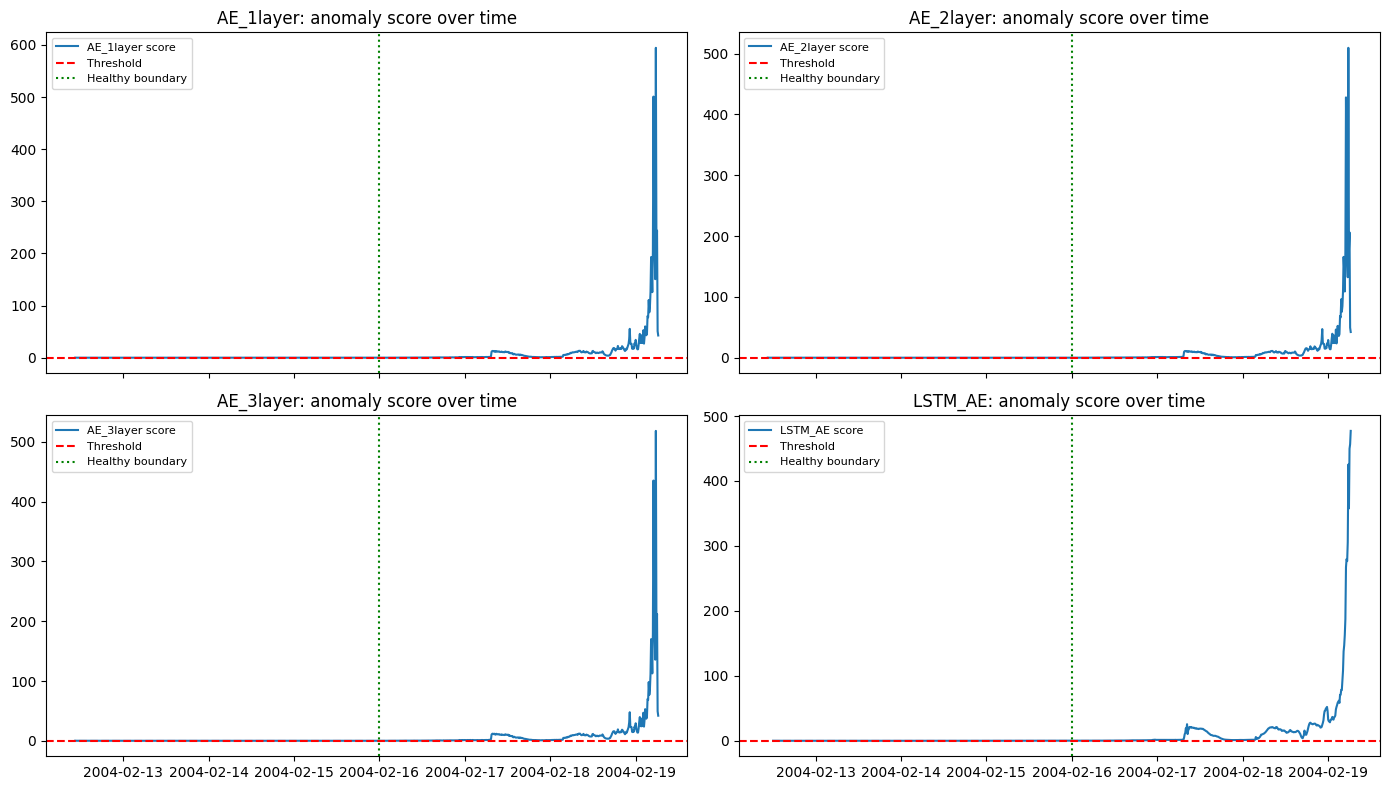

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, name in zip(axes.flat, ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']):
    s = deep_results[name]['scores']
    ax.plot(s.index, s.values, label=f"{name} score")
    ax.axhline(deep_results[name]['threshold'], color='red', linestyle='--', label='Threshold')
    ax.axvline(HEALTHY_BOUNDARY, color='green', linestyle=':', label='Healthy boundary')
    ax.set_title(f"{name}: anomaly score over time")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 17. Final comparison: all models

Four classical plus all four deep (three dense architectures plus LSTM_AE).
Same columns throughout, directly showing
whether deep models add anything over the simpler classical methods.

In [18]:
final_rows = []
for name, r in classical_results.items():
    final_rows.append({'family': 'classical', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val']})
for name in ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']:
    r = deep_results[name]
    final_rows.append({'family': 'deep', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val']})
final_df = pd.DataFrame(final_rows)
display(final_df.style.format({'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,family,model,threshold,first_alarm,fpr_train,fpr_val
0,classical,IsolationForest,0.51205,2004-02-17 01:32:39,0.0341,0.0000
1,classical,OneClassSVM,0.16387,2004-02-16 06:22:39,0.0000,0.0000
2,classical,LOF,1.25941,2004-02-16 06:22:39,0.0219,0.0196
3,classical,PCA,0.12152,2004-02-16 16:42:39,0.0122,0.0098
4,deep,AE_1layer,0.04961,2004-02-16 06:22:39,0.0292,0.0098
5,deep,AE_2layer,0.04203,2004-02-16 06:22:39,0.0170,0.0000
6,deep,AE_3layer,0.04866,2004-02-16 06:22:39,0.0316,0.0098
7,deep,LSTM_AE,0.03550,2004-02-16 06:32:39,0.0323,0.0000


## 18. Deep per feature training

All three dense architectures trained on one feature type at a time, same
procedure as section 13. Slow section, kept only to check whether deep models
rank features the same way classical ones do. LSTM per feature is skipped,
windowed training times six would be too expensive.

In [19]:
deep_feat_rows = []
for arch_name, hidden in [('AE_1layer', [8]), ('AE_2layer', [12, 6]), ('AE_3layer', [16, 8, 4])]:
    for feat in ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']:
        cols = [c for c in df.columns if c.endswith('_' + feat)]
        Xtr_f, Xa_f, sc_f = scale_features(df_healthy_train[cols], df[cols])
        Xva_f = sc_f.transform(df_healthy_val[cols])
        build_f = lambda hl=hidden: build_autoencoder(4, hl)
        mean_full, _ = run_multiple(build_f, Xtr_f, Xa_f,
                                    error_fn=reconstruction_error,
                                    n_runs=3, epochs=50, batch_size=32)
        mean_val, _ = run_multiple(build_f, Xtr_f, Xva_f,
                                   error_fn=reconstruction_error,
                                   n_runs=3, epochs=50, batch_size=32)
        threshold = compute_threshold(mean_val, method="mean_std", n_std=3.0)
        s = pd.Series(mean_full, index=df.index)
        is_an = s > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        train_end = df_healthy_train.index[-1]
        val_end = df_healthy.index[-1]
        fpr_train = float(is_an[(s.index <= train_end)].mean())
        fpr_val = float(is_an[(s.index > train_end) & (s.index <= val_end)].mean())
        deep_feat_rows.append({'arch': arch_name, 'feature': feat,
                               'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                               'fpr_train': round(fpr_train, 4), 'fpr_val': round(fpr_val, 4)})
deep_feat_df = pd.DataFrame(deep_feat_rows)
display(deep_feat_df.pivot_table(index='feature', columns='arch', values='alarm', aggfunc='first', observed=True))

arch,AE_1layer,AE_2layer,AE_3layer
feature,,,
Kurtosis,2004-02-17 06:32:39,2004-02-17 01:32:39,2004-02-17 01:32:39
Peak,2004-02-17 10:12:39,2004-02-17 10:02:39,2004-02-17 10:12:39
RMS,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
Skewness,2004-02-18 12:42:39,2004-02-17 20:42:39,2004-02-18 14:02:39
Std,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39


### Reading the deep per feature table

Only RMS and Std match the joint alarm time of 16.02 06:22. The rest lag into
the next day and later: Kurtosis on 17.02 morning (01:32), Peak on 17.02 around
10:00, Skewness one to two days later depending on the model (17.02 evening through 18.02 midday), CrestFactor never. The order matches the classical per feature table exactly,
so the ranking lives in the data, not in the model. Depth does not change
the ranking, but it moves exact times for weak features: Peak shifts by 10
minutes, Kurtosis by 5 hours, Skewness by up to 16 hours across depths, while
RMS and Std alarm to the minute identically everywhere. Strong signals are
depth invariant, weak ones wobble with architecture.

## 19. Training curves: overfitting check

One model per architecture trained with history kept, plus the LSTM.
Both curves falling and flattening together means healthy training.
Validation rising while train keeps falling would mean memorization.

AE_1layer: final train loss 0.02221, val loss 0.02136


AE_2layer: final train loss 0.01942, val loss 0.01982


AE_3layer: final train loss 0.02143, val loss 0.02058


LSTM_AE: final train loss 0.02410, val loss 0.02586


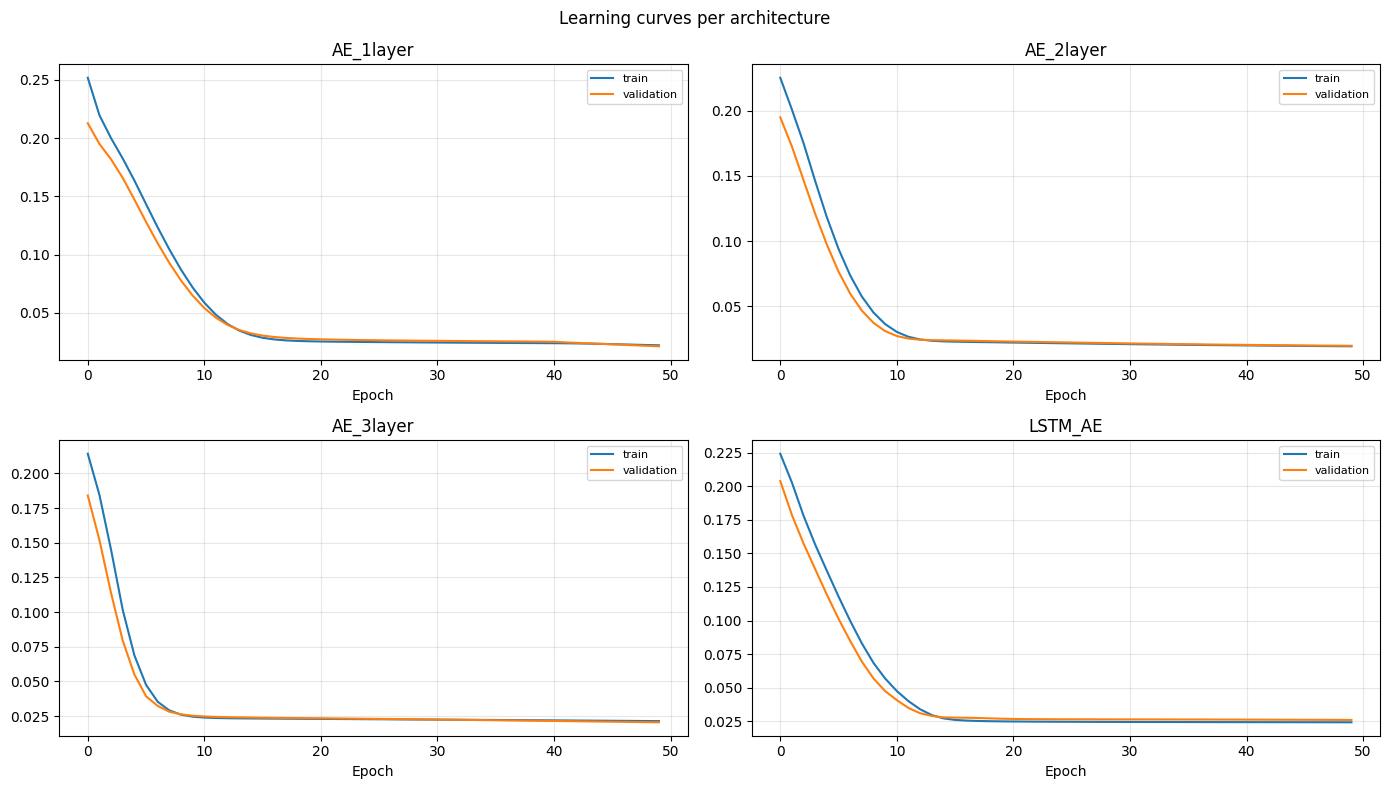

In [19]:
from src.deep_models import train_autoencoder

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, name, build in [
    (axes[0, 0], 'AE_1layer', lambda: build_autoencoder(input_dim, [8])),
    (axes[0, 1], 'AE_2layer', lambda: build_autoencoder(input_dim, [12, 6])),
    (axes[1, 0], 'AE_3layer', lambda: build_autoencoder(input_dim, [16, 8, 4])),
    (axes[1, 1], 'LSTM_AE', lambda: build_lstm_autoencoder(WINDOW_SIZE, input_dim, encoding_dim=8)),
]:
    if name == 'LSTM_AE':
        Xtr_c, Xva_c = X_healthy_windows, X_val_windows
    else:
        Xtr_c, Xva_c = X_healthy_train, X_healthy_val
    m, hist = train_autoencoder(build(), Xtr_c, epochs=50, batch_size=32, seed=0)
    print(f"{name}: final train loss {hist.history['loss'][-1]:.5f}, val loss {hist.history['val_loss'][-1]:.5f}")
    ax.plot(hist.history['loss'], label='train')
    ax.plot(hist.history['val_loss'], label='validation')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Learning curves per architecture')
plt.tight_layout()
plt.show()